In [26]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# res='1km';t_res='5min'
# Np_str='1e6'

# dx = 1km; Np = 50M
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'


# dx = 250 m
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [27]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [28]:
###########################
#Plotting
plotting=False #KEEP FALSE WHEN JOB ARRAYS IS RUNNING
plotting=True

In [29]:
#thresholds
w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6
dir2=dir+'Project_Algorithms/Domain_Profiles/'

currently on type general
currently on type cloudy
(0.09205740114006633, 4.132189709973481)
(-0.14451885014206772, 0.1462443422917333)


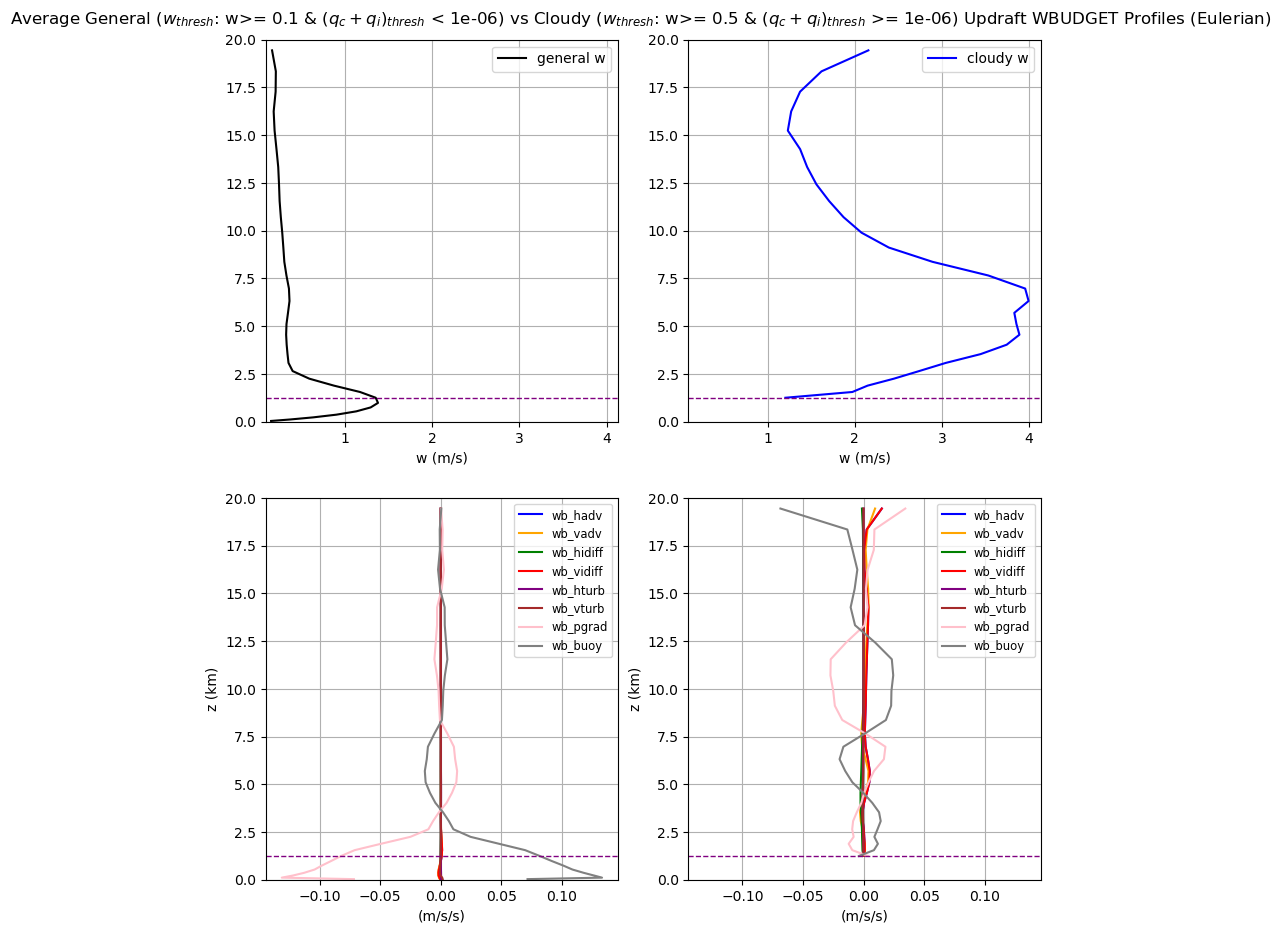

In [30]:
if plotting==True:
    #WBUDGET
    label=1
    
    import h5py
    #Produced averaged profiles for plotting
    def averaged_profiles(var):
        profile=globals()[f"profile_{var}"]
    
        out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
        out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
        return out_var
    
    ####################################################################
    dim='1km'
    # dim='250m'
    label=1
    
    #Uses Plotting Function 
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    plt.subplots_adjust(top=0.95)
    
    fig.suptitle(f"Average General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft WBUDGET Profiles (Eulerian)")
    ax1, ax2, ax3, ax4 = axs.flatten()
    
    ####################################################################
    for type in ["general","cloudy"]:
        print(f'currently on type {type}')
        
        if type == "general":
            input_file = dir2+f'job_out/W_BUDGET_general_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 
        elif type == "cloudy":
            input_file = dir2+f'job_out/W_BUDGET_cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 
        
        with h5py.File(input_file, 'r') as f:
            profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
            profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
            profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
            profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
            profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
            profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
            profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
            profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
            profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy
            
    
    
        #Plotting function
        def plotting_func(out_var,axis,label,color):
            axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
            axis.grid(True)
        
        #Uses Averaged_Profiles Function
        vars = [
        'w',
        'wb_hadv',
        'wb_vadv',
        'wb_hidiff',
        'wb_vidiff',
        'wb_hturb',
        'wb_vturb',
        'wb_pgrad',
        'wb_buoy'
    ]
        colors = [
        'black',    
        'blue',     
        'orange',   
        'green',    
        'red',      
        'purple',   
        'brown',    
        'pink',     
        'grey',
        'cyan'
    ]
    
        for var in vars:
            globals()[f"out_{var}"]=averaged_profiles(var)
    
        # for var in vars:
        #     out_profile=globals()[f"out_{var}"]
        #     minmax=(np.min(out_profile[:,0]),np.max(out_profile[:,0]))
    
        if type=='general':
            axis=ax1
            plotting_func(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
            axis.set_ylim(bottom=0,top=20)
            axis.set_xlabel('w (m/s)')
            axis.legend()
            axis=ax3
        if type=='cloudy':
            axis=ax2
            plotting_func(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
            axis.set_ylim(bottom=0,top=20)
            axis.set_xlabel('w (m/s)')
            axis.legend()
            axis=ax4
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            plotting_func(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylim(bottom=0,top=20)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(m/s/s)')
            axis.legend(fontsize='small'); #add legend
    
    #FIXING X LIMITS
    fix_x_limits([ax1, ax2])
    fix_x_limits([ax3, ax4])
    
    #MEAN CLOUD BASE
    axises=[ax1,ax2,ax3,ax4]
    w_profile=averaged_profiles('w')
    cloudbase=w_profile[0,1]
    for axis in axises:
        axis.axhline(cloudbase,color='purple',linestyle='dashed',linewidth=1)
    
    #save plot
    if dim=='1km':
        plt.savefig(dir+f'Project_Algorithms/plots/1km_eulerian_generalvscloudy_updraft_WBUDGET_profile_wthresh{label}.jpg', bbox_inches='tight', dpi=300) 
    # if dim=='250m'

currently on type general
currently on type cloudy
(-0.8330333588400266, 17.598110104113392)
(-0.007401761541547159, 0.010185223024968174)


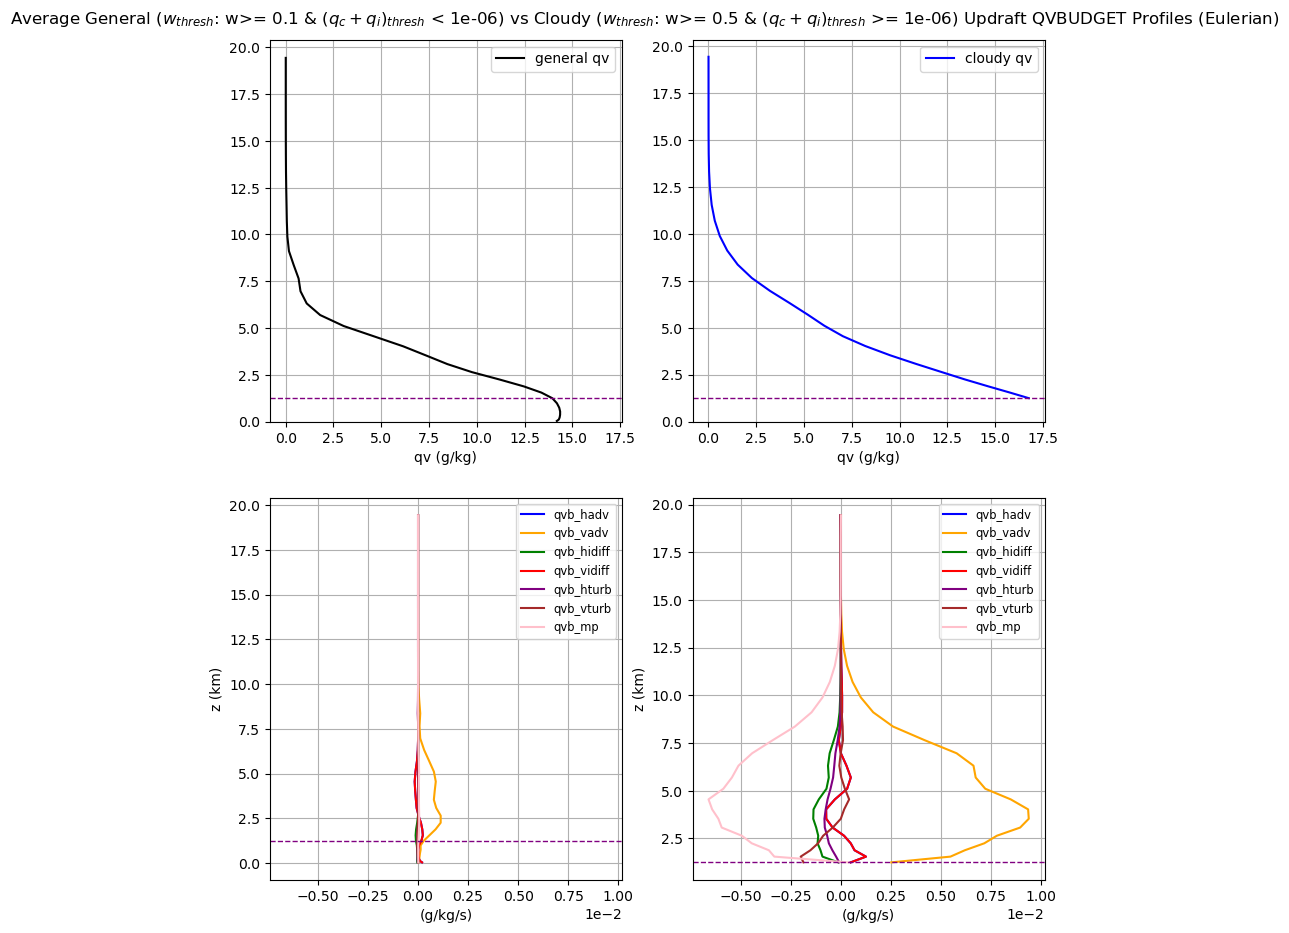

In [31]:
if plotting==True:
    #QV BUDGETS
    from matplotlib.ticker import ScalarFormatter
    label=1
    
    import h5py
    #Produced averaged profiles for plotting
    def averaged_profiles(var):
        profile=globals()[f"profile_{var}"]
    
        out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
        out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
        return out_var
    
    ####################################################################
    dim='1km'
    label=1
    
    #Uses Plotting Function 
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    plt.subplots_adjust(top=0.95)
    
    fig.suptitle(f"Average General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft QVBUDGET Profiles (Eulerian)")
    ax1, ax2, ax3, ax4 = axs.flatten()
    
    ####################################################################
    for type in ["general","cloudy"]:
        print(f'currently on type {type}')
        
        if type == "general":
            input_file = dir2+f'job_out/QV_BUDGET_general_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 
        elif type == "cloudy":
            input_file = dir2+f'job_out/QV_BUDGET_cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}.h5'
        
        with h5py.File(input_file, 'r') as f:
            profile_qv = np.array(f['profile_qv'])  
            profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  
            profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  
            profile_qvb_hidiff = np.array(f['profile_qvb_hidiff']) 
            profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])   
            profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  
            profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  
            profile_qvb_mp = np.array(f['profile_qvb_mp']) 
    
        #Plotting function
        def plotting_func(out_var,axis,label,color):
            axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
            axis.grid(True)
        
        #Uses Averaged_Profiles Function
        vars = [
            'qv',
            'qvb_hadv',
            'qvb_vadv',
            'qvb_hidiff',
            'qvb_vidiff',
            'qvb_hturb',
            'qvb_vturb',
            'qvb_mp'
        ]
        
        colors = [
        'black',    
        'blue',     
        'orange',   
        'green',    
        'red',      
        'purple',   
        'brown',    
        'pink',     
        'grey',
        'cyan'
    ]
    
        for var in vars:
            globals()[f"out_{var}"]=averaged_profiles(var)
            globals()[f"out_{var}"][:,0]*=1000
    
        if type=='general':
            axis=ax1
            plotting_func(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
            axis.set_ylim(bottom=0)
            axis.set_xlabel('qv (g/kg)')
            axis.legend()
            axis=ax3
        if type=='cloudy':
            axis=ax2
            plotting_func(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
            axis.set_ylim(bottom=0)
            axis.set_xlabel('qv (g/kg)')
            axis.legend()
            axis=ax4
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            plotting_func(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(g/kg/s)')
            axis.legend(fontsize='small'); #add legend
            axis.xaxis.set_major_formatter(ScalarFormatter())
            axis.xaxis.get_major_formatter().set_powerlimits((-1, 1))  # Set limits for scientific notation
    
    #FIXING X LIMITS
    fix_x_limits([ax1, ax2])
    fix_x_limits([ax3, ax4])
    
    #MEAN CLOUD BASE
    axises=[ax1,ax2,ax3,ax4]
    w_profile=averaged_profiles('w')
    cloudbase=w_profile[0,1]
    for axis in axises:
        axis.axhline(cloudbase,color='purple',linestyle='dashed',linewidth=1)
    
                
    #save plot
    if dim=='1km':
        plt.savefig(dir+f'Project_Algorithms/plots/1km_eulerian_generalvscloudy_updraft_QVBUDGET_profile_wthresh{label}.jpg', bbox_inches='tight', dpi=300) 
    #limited

currently on type general
currently on type cloudy
(296.3573967828887, 461.41463974766384)
(-0.07375382287107218, 0.047249381224105165)


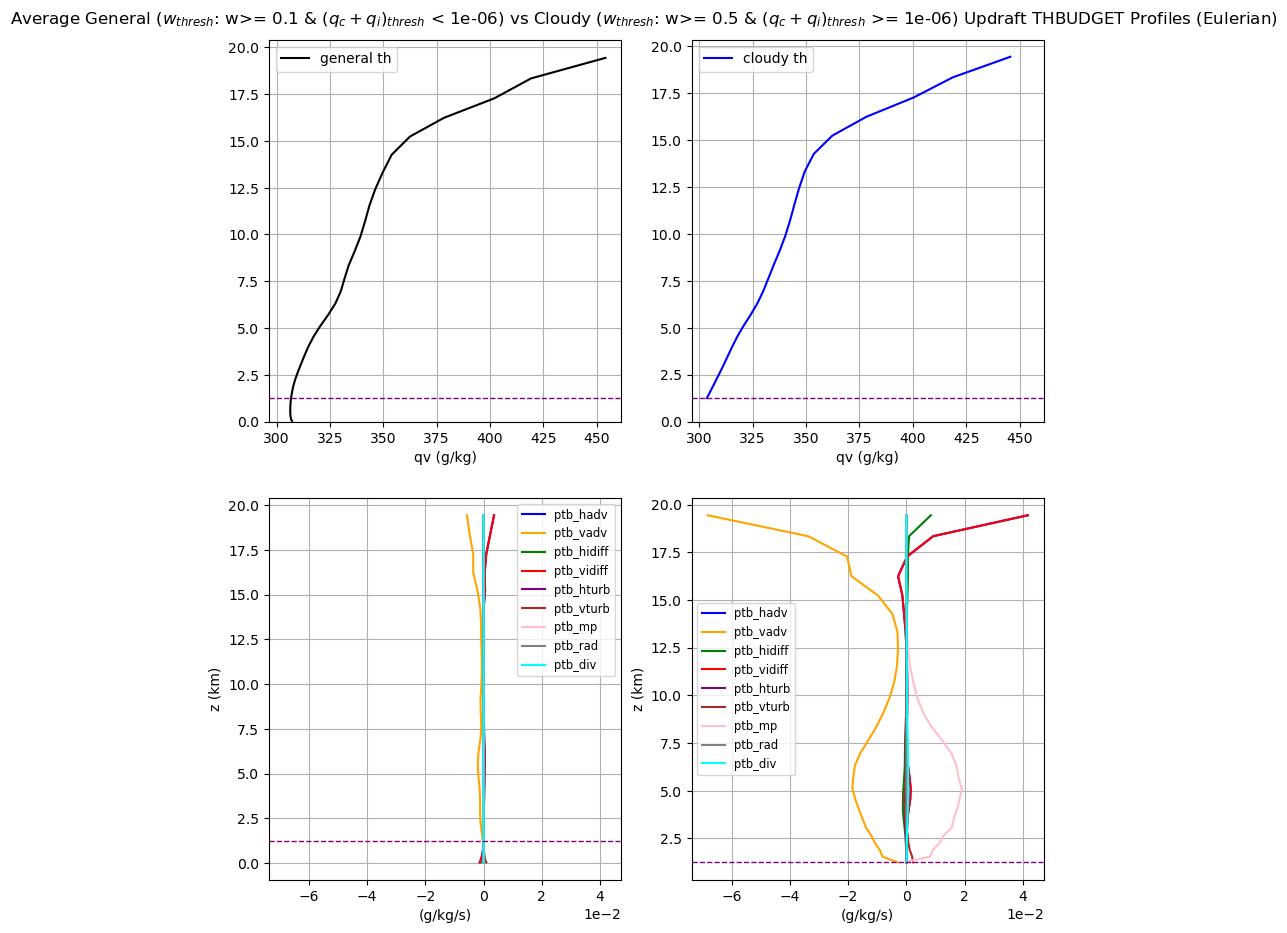

In [32]:
if plotting==True:
    #TH BUDGETS
    from matplotlib.ticker import ScalarFormatter
    label=1
    
    import h5py
    #Produced averaged profiles for plotting
    def averaged_profiles(var):
        profile=globals()[f"profile_{var}"]
    
        out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
        out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
        return out_var
    
    ####################################################################
    dim='1km'
    label=1
    
    #Uses Plotting Function 
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    plt.subplots_adjust(top=0.95)
    
    fig.suptitle(f"Average General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft THBUDGET Profiles (Eulerian)")
    ax1, ax2, ax3, ax4 = axs.flatten()
    
    ####################################################################
    for type in ["general","cloudy"]:
        print(f'currently on type {type}')
        
        if type == "general":
            input_file = dir2+f'job_out/TH_BUDGET_general_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 
        elif type == "cloudy":
            input_file = dir2+f'job_out/TH_BUDGET_cloudy_eulerian_profiles_{res}_{t_res}_{Np_str}.h5' 
        
        with h5py.File(input_file, 'r') as f:
            profile_th = np.array(f['profile_th'])  
            profile_ptb_hadv = np.array(f['profile_ptb_hadv'])  
            profile_ptb_vadv = np.array(f['profile_ptb_vadv'])  
            profile_ptb_hidiff = np.array(f['profile_ptb_hidiff']) 
            profile_ptb_vidiff = np.array(f['profile_ptb_vidiff'])  
            profile_ptb_hturb = np.array(f['profile_ptb_hturb'])  
            profile_ptb_vturb = np.array(f['profile_ptb_vturb'])  
            profile_ptb_mp = np.array(f['profile_ptb_mp']) 
            profile_ptb_rad = np.array(f['profile_ptb_rad']) 
            profile_ptb_div = np.array(f['profile_ptb_div']) 
            profile_ptb_diss = np.array(f['profile_ptb_diss']) 
    
        #Plotting function
        def plotting_func(out_var,axis,label,color):
            axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
            axis.grid(True)
        
        #Uses Averaged_Profiles Function
        vars = [
            'th',
            'ptb_hadv',
            'ptb_vadv',
            'ptb_hidiff',
            'ptb_vidiff',
            'ptb_hturb',
            'ptb_vturb',
            'ptb_mp',
            'ptb_rad',
            'ptb_div',
            'ptb_diss'
        ]
        
        colors = [
        'black',    
        'blue',     
        'orange',   
        'green',    
        'red',      
        'purple',   
        'brown',    
        'pink',     
        'grey',
        'cyan'
    ]
    
        for var in vars:
            globals()[f"out_{var}"]=averaged_profiles(var)
    
        if type=='general':
            axis=ax1
            plotting_func(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
            axis.set_ylim(bottom=0)
            axis.set_xlabel('qv (g/kg)')
            axis.legend()
            axis=ax3
        if type=='cloudy':
            axis=ax2
            plotting_func(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
            axis.set_ylim(bottom=0)
            axis.set_xlabel('qv (g/kg)')
            axis.legend()
            axis=ax4
        for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
            plotting_func(globals()[f"out_{var}"],axis,label=xlabel,color=color)
            axis.set_ylabel('z (km)');
            axis.set_xlabel('(g/kg/s)')
            axis.legend(fontsize='small'); #add legend
            axis.xaxis.set_major_formatter(ScalarFormatter())
            axis.xaxis.get_major_formatter().set_powerlimits((-1, 1))  # Set limits for scientific notation
    
    #FIXING X LIMITS
    fix_x_limits([ax1, ax2])
    fix_x_limits([ax3, ax4])
    
    #MEAN CLOUD BASE
    axises=[ax1,ax2,ax3,ax4]
    w_profile=averaged_profiles('w')
    cloudbase=w_profile[0,1]
    for axis in axises:
        axis.axhline(cloudbase,color='purple',linestyle='dashed',linewidth=1)
    
                
    #save plot
    if dim=='1km':
        plt.savefig(dir+f'Project_Algorithms/plots/1km_eulerian_generalvscloudy_updraft_THBUDGET_profile_wthresh{label}.jpg', bbox_inches='tight', dpi=300) 
    #limited